# Tugas Praktikum - Simple & Multiple Linear Regression

**Nama** : Christina Adelia Sitinjak  
**NIM** : 42324056    

## Tugas 1 - Simple Linear Regression
Prediksi **Scores** berdasarkan **Hours** belajar.

Dataset: [student-score-suitable-for-linear-regression](https://www.kaggle.com/datasets/snmahsa/student-score-suitable-for-linear-regression)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df = pd.read_csv('rounded_hours_student_scores.csv')
df.head()

,Hours,Scores
0,1.1,41
1,1.2,40
2,1.4,38
3,1.5,39
4,1.6,36


**Penjelasan:** Kode di atas untuk membuka dataset jam belajar dan nilai murid, terus tampilkan 5 baris pertama pakai `.head()`. Ini langkah pertama yang penting buat memastikan datanya kebaca dengan benar, kolom-kolomnya sesuai (di sini ada `Hours` dan `Scores`), dan nggak ada format aneh sebelum lanjut ke tahap modeling.

In [3]:
X = df.iloc[:, :-1].values
y = df.iloc[:, 1].values

**Penjelasan:** `X` = jam belajar, `y` = nilai yang mau diprediksi.

`df.iloc[:, :-1]` artinya ambil semua kolom **kecuali** kolom paling terakhir — dalam kasus ini cuma kolom `Hours` doang, tapi dibentuk sebagai array 2D karena scikit-learn memang minta format begitu untuk `X` (fitur/input). Sedangkan `df.iloc[:, 1]` ambil kolom index ke-1 yaitu `Scores`, disimpan sebagai `y` (target/label yang mau ditebak). Pemisahan `X` dan `y` ini standar banget di machine learning: `X` itu yang jadi bahan buat nebak, `y` itu yang mau ditebak.

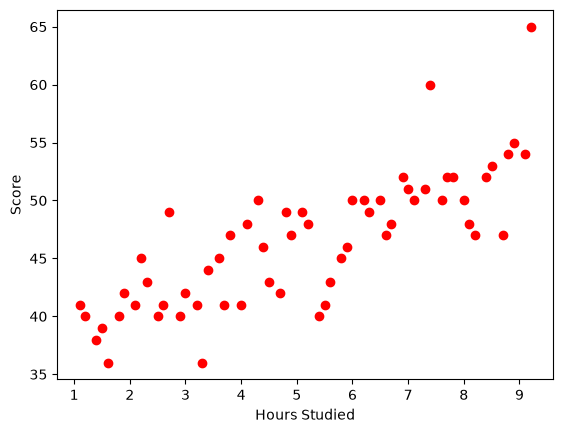

In [4]:
plt.scatter(X, y, color="red")
plt.xlabel('Hours Studied')
plt.ylabel('Score')
plt.show()

**Penjelasan:** Makin lama belajar, nilainya cenderung naik - polanya kelihatan lumayan lurus.

Titik-titiknya naik dari kiri bawah ke kanan atas, itu tandanya ada hubungan **positif** antara jam belajar dan nilai. Karena polanya kelihatan cukup rapi dan mengikuti garis lurus (bukan melengkung atau acak), data ini cocok dimodelkan pakai **regresi linear**, jika polanya melengkung atau random, regresi linear biasa nggak akan pas.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

**Penjelasan:** Data dibagi 80% training, 20% testing.

Kenapa harus dipisah? Karena kita nggak mau model cuma "hafal" data yang dia lihat pas belajar, kita mau tahu apakah dia benar-benar bisa **generalisasi** ke data baru yang belum pernah dilihat. Makanya 80% data (`X_train`, `y_train`) dipakai buat melatih model, dan 20% sisanya (`X_test`, `y_test`) disimpan khusus buat ngetes performanya nanti. `random_state=0` dipakai supaya pembagian datanya selalu sama tiap kali kode dijalankan ulang, jadi hasilnya konsisten dan bisa dibandingkan.

In [6]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.67]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,37.89
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[16.24]


**Penjelasan:** Model belajar pola dari data training.

`LinearRegression()` bikin objek model regresi yang masih "kosong" (belum tahu apa-apa). Baru pas dipanggil `.fit(X_train, y_train)`, model ini mulai "belajar": dia nyari garis lurus yang paling pas buat menggambarkan hubungan antara jam belajar dan nilai, dengan cara meminimalkan selisih (error) antara garis prediksi dan titik-titik data asli. Metode yang dipakai di balik layar namanya *least squares*.

In [7]:
a = regressor.intercept_
b = regressor.coef_[0]

print("Estimated model intercept, a:", a)
print("Estimated model slope, b:", b)
print(f"y_hat = {a:.2f} + {b:.2f}x")

Estimated model intercept, a: 37.89028997006413
Estimated model slope, b: 1.6690585851433417
y_hat = 37.89 + 1.67x


**Penjelasan:** Persamaannya ŷ = 37.89 + 1.67x - tiap nambah 1 jam belajar, nilai diprediksi naik 1.67 poin.

- **a (intercept)** = nilai prediksi y pas x = 0. Kalau misalnya seorang murid belajar 0 jam sama sekali, model bakal prediksi nilainya sekitar 37.89. Perlu diingat, ini cuma titik acuan garis matematis, belum tentu representasi kondisi nyata (soalnya jarang ada murid yang belajar 0 jam persis).
- **b (slope/kemiringan)** = 1.67, artinya tiap nambah 1 jam belajar, nilai yang diprediksi naik sekitar 1.67 poin. Slope-nya positif, jadi arah hubungannya searah: makin lama belajar, makin tinggi nilai yang diprediksi model.

In [8]:
y_pred = regressor.predict(X_test)
y_pred

array([45.73486532, 47.73773562, 53.24562895, 46.06867704, 42.22984229,
       40.22697199, 47.57082976, 53.07872309, 48.90607663, 44.73343017,
       40.56078371, 42.06293643])

**Penjelasan:** Model menebak nilai dari data test.

Di sini model yang sudah dilatih tadi dipakai buat memprediksi nilai murid-murid yang ada di `X_test` — data yang **belum pernah dilihat** model sewaktu training. Hasilnya berupa array angka prediksi nilai untuk tiap murid di data test.

In [9]:
score = r2_score(y_test, y_pred)
score

0.6886702273580021

**Penjelasan:** R²-nya 0.69, cukup lumayan tapi nilai murid kemungkinan juga dipengaruhi faktor lain selain jam belajar.

R² (R-squared) itu ukuran seberapa bagus model bisa menjelaskan variasi data, nilainya antara 0 sampai 1 (semakin dekat ke 1, semakin bagus). R² = 0.69 artinya sekitar **69% variasi nilai murid bisa dijelaskan cuma dari jam belajar saja**. Sisanya 31% kemungkinan dipengaruhi faktor-faktor lain yang tidak ada di dataset ini, misalnya minat belajar, kualitas pengajaran, kondisi kesehatan, dsb. Jadi modelnya sudah cukup baik, tapi belum sempurna, karena nilai ujian jarang cuma ditentukan satu faktor.

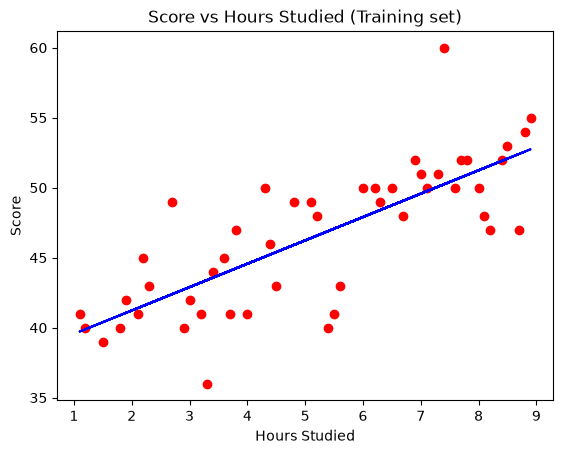

In [10]:
plt.scatter(X_train, y_train, color='red')
plt.plot(X_train, regressor.predict(X_train), color='blue')
plt.title('Score vs Hours Studied (Training set)')
plt.xlabel('Hours Studied')
plt.ylabel('Score')
plt.show()

**Penjelasan:** Garis regresi dibandingin sama data training.

Titik merah itu data asli yang dipakai buat melatih model (`X_train`, `y_train`), garis biru itu garis hasil regresi yang sudah dipelajari model. Kalau garis birunya melewati atau deket dengan sebagian besar titik merah, itu tanda modelnya sudah berhasil menangkap pola dari data training dengan baik.

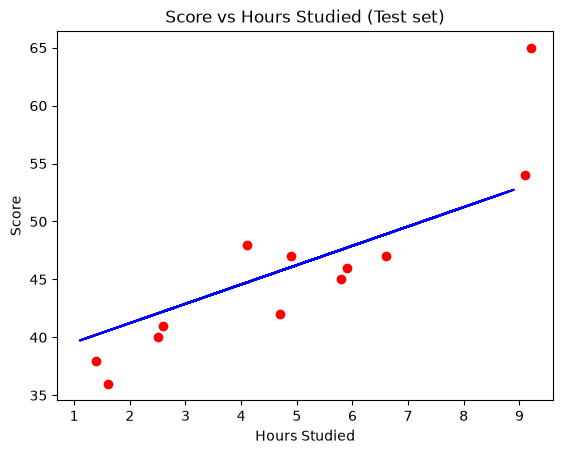

In [11]:
plt.scatter(X_test, y_test, color='red')
plt.plot(X_train, regressor.predict(X_train), color='blue')
plt.title('Score vs Hours Studied (Test set)')
plt.xlabel('Hours Studied')
plt.ylabel('Score')
plt.show()

**Penjelasan:** Sama, tapi dibandingin sama data test.

Bedanya sama grafik sebelumnya, sekarang titik merahnya adalah data test, data yang **tidak** dipakai buat melatih model. Garis birunya tetap sama, yaitu garis hasil belajar dari data training tadi. Grafik ini dipakai untuk mengecek apakah garis yang sudah dipelajari dari data training tetap cocok atau bisa diandalkan untuk data baru yang belum pernah dilihat model — kalau garisnya masih deket sama titik-titik merah, berarti model cukup bagus dalam generalisasi.

## Tugas 2 - Multiple Linear Regression
Prediksi **Sales** dari biaya marketing di **Youtube**, **Facebook**, **Newspaper**.

Dataset: [marketing-linear-multiple-regression](https://www.kaggle.com/datasets/fayejavad/marketing-linear-multiple-regression)

In [12]:
# encoding='utf-8-sig' biar nama kolom 'youtube' kebaca bersih (ada BOM di file aslinya)
df2 = pd.read_csv('Marketing_Data.csv', encoding='utf-8-sig')
df2.head()

,youtube,facebook,newspaper,sales
0,84.72,19.20,48.96,12.60
1,351.48,33.96,51.84,25.68
2,135.48,20.88,46.32,14.28
3,116.64,1.80,36.00,11.52
4,318.72,24.00,0.36,20.88


**Penjelasan:** Buka dataset marketing yang isinya biaya iklan di 3 platform dan hasil sales.

Dataset ini isinya biaya iklan yang dikeluarkan di tiga platform berbeda — `youtube`, `facebook`, `newspaper` — dan hasil penjualan (`sales`) yang didapat. Ditambahkan `encoding='utf-8-sig'` karena file CSV aslinya punya karakter tersembunyi (BOM/Byte Order Mark) di awal file, yang kalau tidak ditangani bisa bikin nama kolom pertama (`youtube`) kebaca aneh atau ada karakter siluman menempel di depannya.

In [13]:
X2 = df2.iloc[:, :-1]
y2 = df2.iloc[:, 3]

**Penjelasan:** `X2` isinya 3 kolom (youtube, facebook, newspaper), `y2` = sales.

Bedanya dengan Tugas 1 tadi: kali ini `X2` punya **3 kolom fitur sekaligus** (youtube, facebook, newspaper), bukan cuma 1. Sedangkan `y2` tetap satu kolom target, yaitu `sales`. Karena modelnya belajar dari lebih dari satu variabel input, inilah yang disebut **Multiple Linear Regression** — beda dengan Simple Linear Regression yang cuma pakai 1 variabel input.

In [14]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=0)

**Penjelasan:** Data dibagi 80:20 lagi buat train dan test.

Sama seperti Tugas 1, alasannya juga sama: biar model bisa dievaluasi pakai data yang belum pernah dilihat sewaktu training, supaya hasil evaluasinya jujur dan tidak bias.

In [15]:
regressor2 = LinearRegression()
regressor2.fit(X_train2, y_train2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.04,0.18,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['youtube','facebook','newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.856
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


**Penjelasan:** Model belajar dari 3 variabel marketing sekaligus.

Prosesnya sama seperti sebelumnya (pakai `LinearRegression()` dan `.fit()`), tapi sekarang model mencari hubungan linear terbaik dari **3 variabel input sekaligus** untuk menjelaskan `sales`. Kalau di Simple Linear Regression hasilnya berupa garis lurus 2D, di Multiple Linear Regression dengan 3 variabel, bentuknya lebih seperti bidang datar (hyperplane) di ruang berdimensi lebih tinggi yang susah digambar langsung, tapi prinsipnya tetap sama: mencari kombinasi linear terbaik dari semua variabel input.

In [16]:
y_pred2 = regressor2.predict(X_test2)
y_pred2

array([17.47637032, 16.37438329, 23.03375348, 24.76366742, 18.44000541,
        9.88587684, 27.58148165, 28.87880859, 23.06393669, 19.0636305 ,
       13.21803757, 14.34999561,  9.23890874, 13.14124811, 10.24291776,
       16.2522827 , 20.0147228 , 25.73237296, 12.05155149, 13.89264368,
       19.7192218 , 10.95264453, 22.23454235, 27.70965086, 20.47231834,
       11.94972356, 19.4677982 , 15.98774074, 23.2733346 , 20.3406546 ,
       25.5594432 , 18.45251872,  6.66383729, 20.57898229, 18.94707082])

**Penjelasan:** Model nebak sales dari data test.

Model yang sudah dilatih dipakai untuk memprediksi `sales` berdasarkan kombinasi biaya iklan di tiga platform (`X_test2`), yang belum pernah dilihat model sewaktu training.

In [17]:
a_ = regressor2.intercept_
b1 = regressor2.coef_[0]
b2 = regressor2.coef_[1]
b3 = regressor2.coef_[2]

print("Estimated model intercept, a:", a_)
print("Estimated model slope, b1 (youtube):", b1)
print("Estimated model slope, b2 (facebook):", b2)
print("Estimated model slope, b3 (newspaper):", b3)
print(f"y_hat = {a_:.4f} + {b1:.4f}x1 + {b2:.4f}x2 + {b3:.4f}x3")

Estimated model intercept, a: 3.8558434315881716
Estimated model slope, b1 (youtube): 0.04381266146268516
Estimated model slope, b2 (facebook): 0.18387483267122112
Estimated model slope, b3 (newspaper): 0.00480963406943527
y_hat = 3.8558 + 0.0438x1 + 0.1839x2 + 0.0048x3


**Penjelasan:** Koefisien facebook (0.18) paling besar - artinya facebook paling efektif dorong sales dibanding youtube dan newspaper.

- **a (intercept)** = prediksi sales kalau budget iklan di ketiga platform sama-sama 0 (titik acuan garis, bukan berarti realistis di dunia nyata).
- **b1, b2, b3** = koefisien untuk masing-masing variabel (`youtube`, `facebook`, `newspaper`). Tiap koefisien menunjukkan seberapa besar pengaruh kenaikan 1 unit budget di platform tersebut terhadap sales, **dengan asumsi budget di platform lain tetap (tidak berubah)**.
- Karena koefisien `facebook` paling besar dibanding `youtube` dan `newspaper`, artinya **tiap tambahan budget di Facebook memberikan dampak kenaikan sales paling besar** dibanding platform lain. Ini insight yang berguna kalau perusahaan mau tahu platform mana yang paling worth-it buat ditambah anggarannya.

In [18]:
score2 = r2_score(y_test2, y_pred2)
score2

0.9227472153504572

**Penjelasan:** R²-nya 0.92, model ini udah cukup akurat buat prediksi sales.

R² = 0.92 artinya sekitar **92% variasi sales bisa dijelaskan** oleh gabungan biaya iklan di youtube, facebook, dan newspaper. Ini jauh lebih tinggi dibanding model Simple Linear Regression di Tugas 1 tadi (R² = 0.69, yang cuma pakai 1 variabel). Ini menunjukkan bahwa menambahkan lebih banyak variabel yang relevan bisa membuat model jauh lebih akurat, asalkan variabel-variabel tersebut memang punya hubungan yang kuat dengan target yang mau diprediksi. Model ini bisa dibilang cukup andal untuk memprediksi sales berdasarkan alokasi budget marketing di ketiga platform tersebut.